# MovieLens 100K Exploratory Data Analysis

This notebook performs a basic exploratory data analysis of the MovieLens 100K dataset.

It focuses on:
- loading the ratings data
- inspecting dataset size
- computing user-item matrix sparsity
- visualizing the rating distribution


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the ratings dataset

In [3]:
ratings = pd.read_csv(
    "../data/raw/movielens/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Basic dataset overview

In [4]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings["user_id"].nunique())
print("Number of items:", ratings["item_id"].nunique())

Number of ratings: 100000
Number of users: 943
Number of items: 1682


## Sparsity of the user-item interaction matrix

A high sparsity value means most user-item pairs have no observed interaction.

In [5]:
num_users = ratings["user_id"].nunique()
num_items = ratings["item_id"].nunique()

sparsity = 1 - len(ratings) / (num_users * num_items)

print("Sparsity:", sparsity)

Sparsity: 0.9369533063577546


## Rating distribution

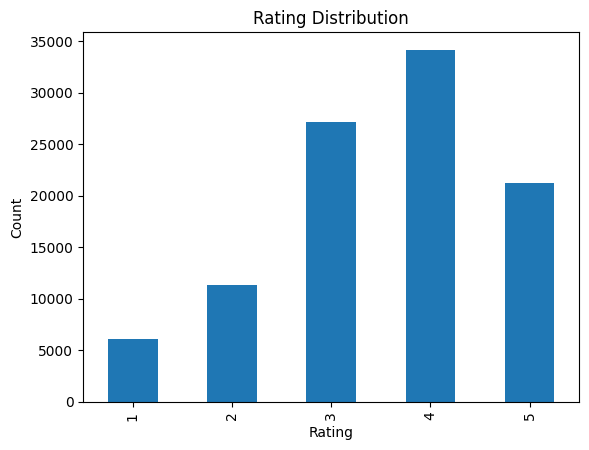

In [6]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Step 1: Create User-Item Matrix

We transform the ratings dataset into a matrix where:
- Rows = Users
- Columns = Movies
- Values = Ratings

This is the foundation of collaborative filtering.

In [7]:
user_item_matrix = ratings.pivot(index="user_id", columns="item_id", values="rating")

print("Matrix Shape:", user_item_matrix.shape)
user_item_matrix.head()

Matrix Shape: (943, 1682)


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2: Normalize Ratings (Mean-Centering)

Users have different rating behaviors:
- Some users give consistently high ratings
- Others are more strict

We normalize ratings by subtracting each user's average rating.

This helps the model focus on **relative preferences** instead of absolute values.

In [8]:
user_means = user_item_matrix.mean(axis=1)

normalized_matrix = user_item_matrix.sub(user_means, axis=0)

normalized_matrix.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.389706,-0.610294,0.389706,-0.610294,-0.610294,1.389706,0.389706,-2.610294,1.389706,-0.610294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.290323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.709677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.125714,0.125714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 3: Handle Missing Values

The user-item matrix is sparse (many missing values).

For similarity computation, we replace missing values with 0.

In [9]:
filled_matrix = normalized_matrix.fillna(0)

### Step 4: Compute User Similarity

We compute similarity between users using cosine similarity.

This helps identify users with similar preferences.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

user_similarity = cosine_similarity(filled_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.iloc[:5, :5]

user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.043411,0.011051,0.059303,0.134514
2,0.043411,1.000000,0.013658,-0.017016,0.035770
3,0.011051,0.013658,1.000000,-0.059638,0.016037
4,0.059303,-0.017016,-0.059638,1.000000,0.007373
5,0.134514,0.035770,0.016037,0.007373,1.000000


### Step 5: Predict Ratings

We estimate ratings for movies a user has not seen.

The prediction is based on:
- Similar users
- Their ratings
- Their similarity weights

Formula intuition:
Predicted Rating = User Mean + Weighted contribution from similar users

In [11]:
import numpy as np

def predict_ratings(user_id, user_item_matrix, user_similarity_df, user_means):
    user_ratings = user_item_matrix.loc[user_id]
    similarities = user_similarity_df.loc[user_id]

    scores = {}

    for movie in user_item_matrix.columns:
        if pd.isna(user_ratings[movie]):

            numerator = 0.0
            denominator = 0.0

            for other_user in user_item_matrix.index:

                other_rating = user_item_matrix.loc[other_user, movie]

                if not pd.isna(other_rating) and other_user != user_id:
                    sim = similarities[other_user]
                    numerator += sim * (other_rating - user_means[other_user])
                    denominator += abs(sim)

            if denominator > 0:
                predicted_rating = user_means[user_id] + (numerator / denominator)
                scores[movie] = predicted_rating

    return scores

### Step 6: Generate Recommendations

We rank predicted ratings and return the top N movies for a user.

In [12]:
def recommend_movies(user_id, user_item_matrix, user_similarity_df, user_means, top_n=5):
    predictions = predict_ratings(user_id, user_item_matrix, user_similarity_df, user_means)

    ranked_movies = sorted(predictions.items(), key=lambda x: x[1], reverse=True)

    return ranked_movies[:top_n]

### Step 7: Test the Model

We test the recommender system for a sample user.

The output shows:
- Movie IDs
- Predicted ratings

In [13]:
recommendations = recommend_movies(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    user_means=user_means,
    top_n=5
)

recommendations

[(1309, np.float64(5.987105711849957)),
 (814, np.float64(5.512809840917499)),
 (1536, np.float64(5.314920452166632)),
 (1467, np.float64(5.129308712090198)),
 (1500, np.float64(5.114487335260533))]

### Step 8: Convert Recommended Movie IDs to Titles

The recommender currently returns:
- movie IDs
- predicted scores

To make results interpretable, we map movie IDs to movie titles and clip predicted ratings to the valid MovieLens range of 1 to 5.

In [17]:
movie_cols = [
    "item_id", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Childrens", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

movies = pd.read_csv(
    "../data/raw/movielens/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    names=movie_cols
)

movies[["item_id", "title"]].head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [18]:
def format_recommendations(recommendations, movies_df):
    formatted = []

    for movie_id, score in recommendations:
        title_row = movies_df[movies_df["item_id"] == movie_id]
        title = title_row["title"].values[0] if not title_row.empty else f"Movie {movie_id}"

        clipped_score = min(max(float(score), 1.0), 5.0)

        formatted.append({
            "movie_id": movie_id,
            "title": title,
            "predicted_rating": round(clipped_score, 3)
        })

    return pd.DataFrame(formatted)

In [19]:
formatted_recs = format_recommendations(recommendations, movies)
formatted_recs

,movie_id,title,predicted_rating
0,1309,"Very Natural Thing, A (1974)",5.0
1,814,"Great Day in Harlem, A (1994)",5.0
2,1536,Aiqing wansui (1994),5.0
3,1467,"Saint of Fort Washington, The (1993)",5.0
4,1500,Santa with Muscles (1996),5.0


### Step 9: Improve Collaborative Filtering with Top-K Neighbors

The initial collaborative filtering model may overestimate ratings because it uses many users when predicting unseen movies.

To make predictions more realistic, we use only the top-K most similar users for each target user.

In [20]:
def predict_ratings_top_k(user_id, user_item_matrix, user_similarity_df, user_means, k=20):
    user_ratings = user_item_matrix.loc[user_id]
    similarities = user_similarity_df.loc[user_id].drop(user_id)

    top_k_users = similarities.sort_values(ascending=False).head(k)

    scores = {}

    for movie in user_item_matrix.columns:
        if pd.isna(user_ratings[movie]):
            numerator = 0.0
            denominator = 0.0

            for other_user, sim in top_k_users.items():
                other_rating = user_item_matrix.loc[other_user, movie]

                if not pd.isna(other_rating):
                    numerator += sim * (other_rating - user_means[other_user])
                    denominator += abs(sim)

            if denominator > 0:
                predicted_rating = user_means[user_id] + (numerator / denominator)
                predicted_rating = min(max(float(predicted_rating), 1.0), 5.0)
                scores[movie] = predicted_rating

    return scores

In [21]:
def recommend_movies_top_k(user_id, user_item_matrix, user_similarity_df, user_means, top_n=5, k=20):
    predictions = predict_ratings_top_k(
        user_id=user_id,
        user_item_matrix=user_item_matrix,
        user_similarity_df=user_similarity_df,
        user_means=user_means,
        k=k
    )

    ranked_movies = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    return ranked_movies[:top_n]

In [22]:
recommendations_top_k = recommend_movies_top_k(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    user_means=user_means,
    top_n=5,
    k=20
)

formatted_top_k = format_recommendations(recommendations_top_k, movies)
formatted_top_k

,movie_id,title,predicted_rating
0,279,Once Upon a Time... When We Were Colored (1995),5.0
1,317,In the Name of the Father (1993),5.0
2,408,"Close Shave, A (1995)",5.0
3,414,My Favorite Year (1982),5.0
4,489,Notorious (1946),5.0


### Step 10: Inspect Truly Raw Predicted Scores

The previous prediction function clips values into the range [1, 5], which hides whether the model is overestimating ratings.

To diagnose the model correctly, we create a version that returns raw predicted scores without clipping.

In [24]:
def predict_ratings_top_k_raw(user_id, user_item_matrix, user_similarity_df, user_means, k=20):
    user_ratings = user_item_matrix.loc[user_id]
    similarities = user_similarity_df.loc[user_id].drop(user_id)

    top_k_users = similarities.sort_values(ascending=False).head(k)

    scores = {}

    for movie in user_item_matrix.columns:
        if pd.isna(user_ratings[movie]):
            numerator = 0.0
            denominator = 0.0

            for other_user, sim in top_k_users.items():
                other_rating = user_item_matrix.loc[other_user, movie]

                if not pd.isna(other_rating):
                    numerator += sim * (other_rating - user_means[other_user])
                    denominator += abs(sim)

            if denominator > 0:
                predicted_rating = user_means[user_id] + (numerator / denominator)
                scores[movie] = float(predicted_rating)

    return scores

In [25]:
raw_predictions = predict_ratings_top_k_raw(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    user_means=user_means,
    k=20
)

sorted(raw_predictions.items(), key=lambda x: x[1], reverse=True)[:10]

[(1495, 5.555631738225837),
 (279, 5.512809840917499),
 (414, 5.512809840917499),
 (492, 5.512809840917499),
 (497, 5.512809840917499),
 (519, 5.512809840917499),
 (656, 5.512809840917499),
 (661, 5.512809840917499),
 (733, 5.512809840917499),
 (811, 5.512809840917499)]

### Step 11: Use Ranking Score Instead of Raw Rating Prediction

Instead of predicting exact ratings, we compute a recommendation score based on similarity-weighted ratings.

This helps better rank movies for recommendation.

In [26]:
def predict_scores_ranking(user_id, user_item_matrix, user_similarity_df, k=20):
    user_ratings = user_item_matrix.loc[user_id]
    similarities = user_similarity_df.loc[user_id].drop(user_id)

    similarities = similarities[similarities > 0]
    top_k_users = similarities.sort_values(ascending=False).head(k)

    scores = {}

    for movie in user_item_matrix.columns:
        if pd.isna(user_ratings[movie]):
            score = 0.0

            for other_user, sim in top_k_users.items():
                rating = user_item_matrix.loc[other_user, movie]

                if not pd.isna(rating):
                    score += sim * rating

            scores[movie] = score

    return scores

In [31]:
ranking_scores = predict_scores_ranking(
    user_id=10,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    k=20
)

sorted_ranking = sorted(ranking_scores.items(), key=lambda x: x[1], reverse=True)[:10]

sorted_ranking

[(89, np.float64(10.622752729010697)),
 (172, np.float64(10.386708297486335)),
 (187, np.float64(10.244545305952705)),
 (181, np.float64(9.188676074953776)),
 (318, np.float64(9.182806980917357)),
 (423, np.float64(9.132752444993152)),
 (523, np.float64(9.128356253787429)),
 (204, np.float64(9.127464492557175)),
 (79, np.float64(8.995873117961551)),
 (8, np.float64(8.484585523171539))]

In [32]:
def format_ranking_results(recommendations, movies_df):
    formatted = []

    for movie_id, score in recommendations:
        title_row = movies_df[movies_df["item_id"] == movie_id]
        title = title_row["title"].values[0] if not title_row.empty else f"Movie {movie_id}"

        formatted.append({
            "movie_id": movie_id,
            "title": title,
            "score": round(float(score), 3)
        })

    return pd.DataFrame(formatted)

In [33]:
formatted_ranking = format_ranking_results(sorted_ranking, movies)
formatted_ranking

,movie_id,title,score
0,89,Blade Runner (1982),10.623
1,172,"Empire Strikes Back, The (1980)",10.387
2,187,"Godfather: Part II, The (1974)",10.245
3,181,Return of the Jedi (1983),9.189
4,318,Schindler's List (1993),9.183
5,423,E.T. the Extra-Terrestrial (1982),9.133
6,523,Cool Hand Luke (1967),9.128
7,204,Back to the Future (1985),9.127
8,79,"Fugitive, The (1993)",8.996
9,8,Babe (1995),8.485
